In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
! pip install dagshub mlflow networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 104.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 901.5 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

# Dagshub/Mlflow initialization

In [3]:
import dagshub
import mlflow
import mlflow.sklearn
import os

TOKEN = '773e6d0f45f4f8c8ed729b693f548555a4de31f8'

os.environ['DAGSHUB_USER_TOKEN'] = TOKEN
dagshub.auth.add_app_token(TOKEN)

dagshub.init(repo_owner='sbolk23', repo_name='IEEE-CIS-Fraud-Detection-Kaggle-Competition', mlflow=True)

Accessing as sbolk23

Initialized MLflow to track repo "sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition"

Repository sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition initialized!

In [4]:
TARGET = 'isFraud'

In [5]:
df_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [6]:
print('train_trancation shape:', df_transaction.shape)
print('train_identity shape:',   df_identity.shape)

train_trancation shape: (590540, 394)
train_identity shape: (144233, 41)


In [7]:
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

In [8]:
print('Data count:',  df[TARGET].shape[0])
print('Event count:', df[TARGET].sum())

Data count: 590540
Event count: 20663


In [9]:
sorted_df = df.sort_values(by='TransactionDT')

train_size = int(sorted_df.shape[0] * .7)
val_size   = int(sorted_df.shape[0] * .15)

train_df = sorted_df.iloc[:train_size]
val_df   = sorted_df.iloc[train_size: train_size + val_size]
test_df  = sorted_df.iloc[train_size + val_size:]

print('Train shape:',      train_df.shape, '\nTrain prevalence:',      train_df[TARGET].sum() / train_df.shape[0], '\n')
print('Validation shape:', val_df.shape,   '\nValidation prevalence:', val_df[TARGET].sum()   / val_df.shape[0],   '\n')
print('Test shape:',       test_df.shape,  '\nTrain prevalence:',      test_df[TARGET].sum()  / test_df.shape[0],  '\n')

Train shape: (413378, 434) 
Train prevalence: 0.03516878014795175 

Validation shape: (88581, 434) 
Validation prevalence: 0.03434145019812375 

Test shape: (88581, 434) 
Train prevalence: 0.03480430340592226 



In [10]:
X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

# Data Cleaning

# Removing outlier 

In [11]:
# Fix outliers
outliers = train_df[train_df['TransactionAmt'] >= 30000]

# Remove outliers
train_df = train_df[train_df['TransactionAmt'] < 30000]

# Split train_df into X_train and y_train
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

# High Null Rate Column dropper

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin

class HighNullColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=.9):
        self.threshold = threshold
        self.features_to_drop_ = None
        self.features_to_keep_ = None

    def fit(self, X, y):
        null_ratio = X.isna().mean()

        self.features_to_keep_ = null_ratio[null_ratio <= self.threshold].index.tolist()
        self.features_to_drop_ = null_ratio[null_ratio >  self.threshold].index.tolist()
        
        return self

    def transform(self, X):
        X = X.copy()
        return X[self.features_to_keep_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_keep_)

# V-Columns Correlation Filter

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
from networkx.utils import UnionFind

class VColumnFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=.75):
        self.threshold = threshold
        self.features_to_keep_ = None
        self.v_features_to_keep_ = None
    
    def fit(self, X, y=None):
        non_v_cols = [c for c in X.columns if not c.startswith('V')]
        v_cols = [col for col in X.columns if col.startswith('V')]

        groups = {}
        for col in v_cols:
            na_count = X[col].isna().sum()
            if na_count not in groups:
                groups[na_count] = []
            groups[na_count].append(col)

        self.v_features_to_keep_ = []

        for na_count, cols in groups.items():
            if len(cols) == 1:
                self.v_features_to_keep_.append(cols[0])
                continue

            filled = X[cols].fillna(X[cols].mean())
            corr = filled.corr()
            
            uf = UnionFind(cols)
            for i in range(len(cols)):
                for j in range(i + 1, len(cols)):
                    if abs(corr.iloc[i, j]) >= self.threshold:
                        uf.union(cols[i], cols[j])

            subgroups = {}
            for col in cols:
                root = uf[col]
                if root not in subgroups:
                    subgroups[root] = []
                subgroups[root].append(col)
                
            for subgroup in subgroups.values():
                rep = max(subgroup, key=lambda c: X[c].nunique())
                self.v_features_to_keep_.append(rep)

        self.features_to_keep_ = self.v_features_to_keep_ + non_v_cols
            
        return self
                        
    def transform(self, X):
        return X[self.features_to_keep_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_keep_)

# Time Feature Engineering

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin

class TimeFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, start_date='2017-11-30'):
        self.start_date         = start_date
        self.feature_names_in_  = None
        self.new_features_      = [
            'hour', 'dayofweek', 'day', 'month',
        ]

    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        
        START_DATE   = pd.Timestamp(self.start_date)
        datetime_col = START_DATE + pd.to_timedelta(X['TransactionDT'], unit='s')
        
        X['hour']      = datetime_col.dt.hour
        X['dayofweek'] = datetime_col.dt.dayofweek
        X['day']       = datetime_col.dt.day
        X['month']     = datetime_col.dt.month
        
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_ + self.new_features_)

# *TransactionAmt* Feature Enginnering

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class AmtFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.new_features_ = [
            'amt_log',
        ]
    
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        X['amt_log'] = np.log1p(X['TransactionAmt'])        
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_ + self.new_features_)

# Categorical Column Encoder

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cardinality_threshold=10):
        self.cardinality_threshold = cardinality_threshold
        self.low_card_cols_        = None
        self.high_card_cols_       = None
        self.freq_maps_            = {}
        self.ohe_                  = None
        self.feature_names_out_    = None

    def fit(self, X, y=None):
        cat_cols = X.select_dtypes(include='object').columns.tolist()
        
        self.low_card_cols_  = [c for c in cat_cols if X[c].nunique() <  self.cardinality_threshold]
        self.high_card_cols_ = [c for c in cat_cols if X[c].nunique() >= self.cardinality_threshold]
        
        if self.low_card_cols_:
            self.ohe_ = OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False,
            )
            self.ohe_.fit(X[self.low_card_cols_].fillna('missing'))
        
        for col in self.high_card_cols_:
            self.freq_maps_[col] = X[col].value_counts(normalize=True).to_dict()
        
        ohe_names  = list(self.ohe_.get_feature_names_out(self.low_card_cols_)) if self.low_card_cols_ else []
        freq_names = [f'{c}_freq' for c in self.high_card_cols_]
        num_cols   = X.select_dtypes(include='number').columns.tolist()
        self.feature_names_out_ = num_cols + ohe_names + freq_names
        
        return self

    def transform(self, X):
        X = X.copy()
        parts = []
        
        num_cols = X.select_dtypes(include='number').columns.tolist()
        parts.append(X[num_cols])

        if self.low_card_cols_:
            ohe_array = self.ohe_.transform(X[self.low_card_cols_].fillna('missing'))
            ohe_df    = pd.DataFrame(
                ohe_array,
                columns=self.ohe_.get_feature_names_out(self.low_card_cols_),
                index=X.index
            )
            parts.append(ohe_df)
        
        for col in self.high_card_cols_:
            freq_df = pd.DataFrame(
                X[col].map(self.freq_maps_[col]).fillna(0).values,
                columns=[f'{col}_freq'],
                index=X.index
            )
            parts.append(freq_df)
        
        return pd.concat(parts, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

# UID Aggregations

In [17]:
# from sklearn.base import BaseEstimator, TransformerMixin

# class UIDFeatureAdder(BaseEstimator, TransformerMixin):
     
#     def __init__(self):
#         self.uid_agg_map_ = None   
#         self.uid2_agg_map_ = None 
#         self.feature_names_in_ = None

#     def _build_uids(self, X):
#         D1n  = X['D1'] - X['TransactionDT'] / (23 * 60 * 60)
        
#         uid  = X['card1'].astype(str) + '_' + \
#                X['addr1'].astype(str) + '_' + \
#                D1n.round(0).astype(str)
         
#         uid2 = X['card1'].astype(str) + '_' + \
#                X['addr1'].astype(str)
         
#         return uid, uid2



#     def fit(self, X, y=None):
#         X = X.copy()
#         X['uid'] = X['card1'].astype(str) + '_' + X['addr1'].astype(str)
    
#         self.uid_stats_ = X.groupby('uid').agg(
#             uid_txn_count = ('TransactionAmt', 'count'),
#             uid_amt_mean  = ('TransactionAmt', 'mean'),
#             uid_amt_std   = ('TransactionAmt', 'std'),
#             uid_D2_mean   = ('D2',  'mean'),
#             uid_D15_mean  = ('D15', 'mean'),
#             uid_C1_mean   = ('C1',  'mean'),
#             uid_C9_mean   = ('C9',  'mean'),
#             uid_C11_mean  = ('C11', 'mean'),
#             uid_C13_mean  = ('C13', 'mean'),
#         )
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         X['uid'] = X['card1'].astype(str) + '_' + X['addr1'].astype(str)
    
#         X = X.merge(self.uid_stats_, on='uid', how='left')
#         X['uid_amt_zscore'] = (X['TransactionAmt'] - X['uid_amt_mean']) / (X['uid_amt_std'] + 1e-9)
#         X = X.drop(columns=['uid'])
#         return X

#     def get_feature_names_out(self, input_features=None):
#         return np.array(self.feature_names_in_ + [
#             'uid_txn_count', 
#             'uid_amt_mean', 
#             'uid_amt_std',
#             'uid_D2_mean', 
#             'uid_D15_mean',
#             'uid_C1_mean', 
#             'uid_C9_mean', 
#             'uid_C11_mean', 
#             'uid_C13_mean',
#             'uid_amt_zscore', 
#         ])

#     # def fit(self, X, y=None):
#     #     self.feature_names_in_ = X.columns.tolist()
        
#     #     X = X.copy()
#     #     X['uid'], X['uid2'] = self._build_uids(X)

#     #     self.uid_stats_ = X.groupby('uid').agg(
#     #         uid_txn_count = ('TransactionAmt', 'count'),
#     #         uid_amt_mean  = ('TransactionAmt', 'mean'),
#     #         uid_amt_std   = ('TransactionAmt', 'std'),
#     #         uid_D2_mean   = ('D2',             'mean'),
#     #         uid_D15_mean  = ('D15',            'mean'),
#     #         uid_C1_mean   = ('C1',             'mean'),
#     #         uid_C9_mean   = ('C9',             'mean'),
#     #         uid_C11_mean  = ('C11',            'mean'),
#     #         uid_C13_mean  = ('C13',            'mean'),
#     #     )
        
#     #     self.uid2_stats_ = X.groupby('uid2').agg(
#     #         uid2_amt_mean = ('TransactionAmt', 'mean'),
#     #         uid2_amt_std  = ('TransactionAmt', 'std'),
#     #     )
        
#     #     return self

#     # def transform(self, X, y=None):
#     #     X = X.copy()
#     #     X['uid'], X['uid2'] = self._build_uids(X)

#     #     X = X.merge(self.uid_stats_,  on='uid',  how='left')
#     #     X = X.merge(self.uid2_stats_, on='uid2', how='left')

#     #     X['uid_amt_zscore']  = (X['TransactionAmt'] - X['uid_amt_mean'])  / (X['uid_amt_std']  + 1e-9)
#     #     X['uid2_amt_zscore'] = (X['TransactionAmt'] - X['uid2_amt_mean']) / (X['uid2_amt_std'] + 1e-9)

#     #     X = X.drop(columns=['uid', 'uid2'])
#     #     return X
        
#     # def get_feature_names_out(self, input_features=None):
#     #     return np.array(self.feature_names_in_ + [
#     #         'uid_txn_count', 
#     #         'uid_amt_mean', 
#     #         'uid_amt_std',
#     #         'uid_D2_mean', 
#     #         'uid_D15_mean',
#     #         'uid_C1_mean', 
#     #         'uid_C9_mean', 
#     #         'uid_C11_mean', 
#     #         'uid_C13_mean',
#     #         'uid2_amt_mean', 
#     #         'uid2_amt_std',
#     #         'uid_amt_zscore', 
#     #         'uid2_amt_zscore',
#     #     ])

# Uninformative Columns

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

# TransactionID and TransactionDT are not informative feature so we remove it

irrelevant_cols = [
    'TransactionID',
    'TransactionDT',
]

class IrrelevantColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop=None):
        self.cols_to_drop       = cols_to_drop if cols_to_drop is not None else []
        self.feature_names_out_ = None

    def fit(self, X, y=None):
        self.cols_to_drop_      = [c for c in self.cols_to_drop if c in X.columns]
        self.feature_names_out_ = [c for c in X.columns if c not in self.cols_to_drop_]
        return self

    def transform(self, X):
        return X[self.feature_names_out_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

# Preprocessing Pipeline

In [19]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Full preprocessor pipeline
preprocessor = Pipeline([
    ('time_feature_adder',     TimeFeatureAdder()),
    ('amt_feature_adder',      AmtFeatureAdder()),
    ('irrelevant_col_dropper', IrrelevantColumnDropper()),
    ('high_null_col_dropper',  HighNullColumnDropper()),
    ('v_col_filter',           VColumnFilter()),
    # ('uid_feature_adder',      UIDFeatureAdder()),
    ('cat_encoder',            CategoricalEncoder()),
])

# Full Pipeline

In [20]:
from xgboost import XGBClassifier

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        XGBClassifier()),
])

preprocessor_configs = {
    'cat_encoder__cardinality_threshold': [10],
}

# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':         [1000,], # Number of trees
#     'max_depth':            [4, 5, 6,],     # Tree depth; IEEE sweet spot is usually 6-12
#     'min_child_weight':     [10, 50, 100],    # Higher values prevent overfitting on tiny noise clusters
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     'reg_lambda':           [1, 5, 10],      # L2 regularization (Smooths leaf weights)
#     'reg_alpha':            [0, .1, 1],      # L1 regularization (Encourages feature sparsity)
#     'gamma':                [1, 5],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.01, .05,], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.6, .7],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.5, .6],             # Feature sampling per tree
#     'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }

# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':         [225,], # Number of trees
#     'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
#     'min_child_weight':     [50,],    # Higher values prevent overfitting on tiny noise clusters
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     'reg_lambda':           [2,],      # L2 regularization (Smooths leaf weights)
#     'reg_alpha':            [.5],      # L1 regularization (Encourages feature sparsity)
#     'gamma':                [3,],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.05,], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.8],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.8],             # Feature sampling per tree
#     'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }

# MLflow Logging 

# Model Parameters & Metrics Logging Helper function

In [21]:
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    log_loss, 
    brier_score_loss, 
    f1_score, 
    precision_score, 
    recall_score, 
    balanced_accuracy_score, 
    matthews_corrcoef,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_curve
)

def log_model_parameters_metrics(y_true, y_prob, prefix):
    
    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)

    
    print(f'Logging model metrics on {prefix} set...')
    
    # Metrics independent from threshold
    auc_roc         = roc_auc_score(y_true, y_prob)
    auc_pr          = average_precision_score(y_true, y_prob)
    model_log_loss  = log_loss(y_true, y_prob)
    model_brier     = brier_score_loss(y_true, y_prob)

    mlflow.log_metric(f'{prefix}_auc_roc',  auc_roc)
    mlflow.log_metric(f'{prefix}_auc_pr',   auc_pr)
    mlflow.log_metric(f'{prefix}_log_loss', model_log_loss)
    mlflow.log_metric(f'{prefix}_brier',    model_brier)

    
    # Metrics dependent on best threshold
    model_f1        = f1_score(y_true, y_pred)
    model_precision = precision_score(y_true, y_pred)
    model_recall    = recall_score(y_true, y_pred)
    
    mlflow.log_metric(f'{prefix}_f1',        model_f1)
    mlflow.log_metric(f'{prefix}_precision', model_precision)
    mlflow.log_metric(f'{prefix}_recall',    model_recall)

    # Best threshold
    mlflow.log_metric(f'{prefix}_best_threshold', best_threshold)

    
    # Log confusion matrix and classification report
    cm     = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    
    mlflow.log_text(f'Confusion Matrix:\n{cm}',          f'{prefix}_confusion_matrix.txt')
    mlflow.log_text(f'Classification Report:\n{report}', f'{prefix}_classification_report.txt')


# Model Metrics Curves Logging Helper Function

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def log_model_metrics_curves(y_true, y_prob, prefix):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Log ROC curve
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    ax_roc.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
    ax_roc.plot([0, 1], [0, 1], linestyle='--')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curve - {prefix}')
    ax_roc.legend(loc='lower right')
    mlflow.log_figure(fig_roc, f'{prefix}_roc_curve.png')
    plt.close(fig_roc)

    # Log Precision-Recall curve
    precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recalls, precisions)

    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    ax_pr.plot(recalls, precisions, label=f'PR AUC = {pr_auc:.4f}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall Curve - {prefix}')
    ax_pr.legend(loc='lower left')
    mlflow.log_figure(fig_pr, f'{prefix}_pr_curve.png')
    plt.close(fig_pr)


    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    
    # Log Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {prefix}")
    mlflow.log_figure(fig, f"{prefix}_confusion_matrix.png")

In [23]:
# from sklearn.model_selection import ParameterGrid, GridSearchCV
# from sklearn.base import clone

# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':         [400], # Number of trees
#     # 'early_stopping_rounds': [100],
#     'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
#     'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
#     'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
#     'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.8,],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.8,],             # Feature sampling per tree
#     'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }

# # model_configs = {
# #     # --- Structural Parameters ---
# #     'n_estimators':         [2000], # Number of trees
# #     'early_stopping_rounds': [100],
# #     'max_depth':            [12,],     # Tree depth; IEEE sweet spot is usually 6-12
# #     # 'min_child_weight':     [100],    # Higher values prevent overfitting on tiny noise clusters
    
# #     # --- Inner Regularization (The "Loss Modifiers") ---
# #     # 'reg_lambda':           [100,],      # L2 regularization (Smooths leaf weights)
# #     # 'reg_alpha':            [100,],      # L1 regularization (Encourages feature sparsity)
# #     # 'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
# #     # --- Learning & Sampling ---
# #     'learning_rate':        [.02], # Shrinkage; lower requires more n_estimators
# #     'subsample':            [.8,],             # Row sampling (prevent overfitting)
# #     'colsample_bytree':     [.4,],             # Feature sampling per tree
# #     # 'colsample_bylevel':    [1],             # Feature sampling per level
    
# #     # --- Imbalance & Specialized ---
# #     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
# #     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
# #     # --- Technical Constants ---
# #     'tree_method':          ['hist'],          # Required for large datasets + categorical support
# #     'enable_categorical':   [True],            # Must be True for your cat_pipeline
# #     'random_state':         [1337],
# #     'n_jobs':               [-1],
# #     'eval_metric':          ['auc'],
# #     'device':               ['cuda']
# # }



# for prep_param in ParameterGrid(preprocessor_configs):
#     preprocessor = clone(full_pipeline.named_steps['preprocessor'])
#     preprocessor.set_params(**prep_param)

#     print('Starting fitting & transforming X_train, X_val...')

#     X_train_t = preprocessor.fit_transform(X_train, y_train)
#     print('fit_transform X_train finished...')

#     X_val_t   = preprocessor.transform(X_val)
#     print('transform X_val finished...')

#     # print(prep_param)
#     # print((X_train_t.columns.tolist()))
#     # print(preprocessor.named_steps['v_col_filter'].v_features_to_keep_)
    
#     for model_param in ParameterGrid(model_configs):    
#         model = clone(full_pipeline.named_steps['model'])
#         model.set_params(**model_param)

#         print('Currently running model with params:', model_param)
        
#         print('Starting training model on X_train_t...')
#         # model.fit(
#         #     X_train_t, y_train,
#         #     eval_set=[(X_val_t, y_val)],
#         #     verbose=100,
#         # )
#         model.fit(X_train_t, y_train)
        
#         print('Finished training model on X_train_t...')

#         print('Starting predicting on X_train_t...')
#         y_train_prob = model.predict_proba(X_train_t)[:, 1]
#         print('Finished predicting on X_train_t...')
        
#         print('Starting predicting on X_val_t...')
#         y_val_prob   = model.predict_proba(X_val_t)[:, 1]
#         print('Finished predicting on X_val_t...')

#         print('train_roc_score:', roc_auc_score(y_train, y_train_prob))
#         print('test_roc_score:',  roc_auc_score(y_val, y_val_prob))

Start MLflow logging
Starting fitting & transforming X_train, X_val...
fit_transform X_train finished...
transform X_val finished...
{'cat_encoder__cardinality_threshold': 10}
Currently running model with params: {'colsample_bylevel': 1, 'colsample_bytree': 0.8, 'device': 'cuda', 'enable_categorical': True, 'eval_metric': 'auc', 'gamma': 0, 'learning_rate': 0.05, 'max_delta_step': 0, 'max_depth': 10, 'min_child_weight': 200, 'n_estimators': 400, 'n_jobs': -1, 'random_state': 1337, 'reg_alpha': 500, 'reg_lambda': 500, 'scale_pos_weight': 27.434172513413124, 'subsample': 0.8, 'tree_method': 'hist'}
Starting training model on X_train_t...
Finished training model on X_train_t...
Starting predicting on X_train_t...
Finished predicting on X_train_t...
Starting predicting on X_val_t...
Finished predicting on X_val_t...
train_auc_roc_score: 0.9574160943628736
test_auc_roc_score: 0.9108286834479205
Logging model training results on mlflow...
Loggin model parameters...
Logging model metrics on t

2026/05/07 14:58:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 14:58:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Training__n_estimators_400__max_depth_10__min_child_weight_200__reg_lambda_500__reg_alpha_500__gamma_0__lr_0.05__subsample_0.8__colsample_bytree_0.8__colsample_bylevel_1__scale_pos_weight_27.434172513413124__max_delta_step_0 at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/12/runs/171c5b4d35904a95950ccc50cc72f4ed
🧪 View experiment at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/12


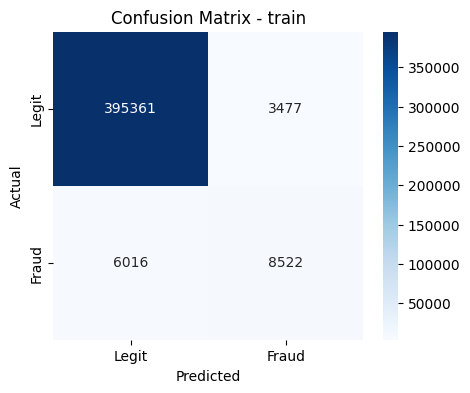

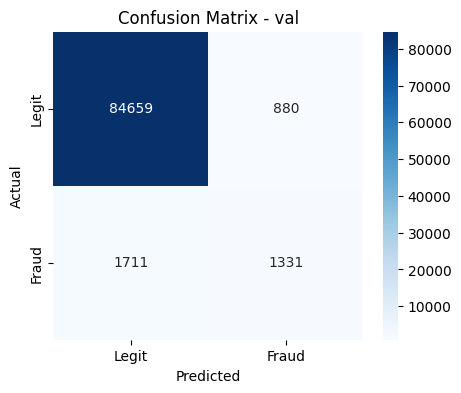

In [26]:
from sklearn.model_selection import ParameterGrid, GridSearchCV
from sklearn.base import clone

# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':         [400], # Number of trees
#     'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
#     'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
#     'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
#     'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.8,],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.85,],             # Feature sampling per tree
#     'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     # 'scale_pos_weight':     [30.0],  # Handle imbalance (Ratio of negative/positive)
#     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }


model_configs = {
    # --- Structural Parameters ---
    'n_estimators':         [400], # Number of trees
    # 'early_stopping_rounds': [100],
    'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
    'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
    # --- Inner Regularization (The "Loss Modifiers") ---
    'reg_lambda':           [500,],      # L2 regularization (Smooths leaf weights)
    'reg_alpha':            [500,],      # L1 regularization (Encourages feature sparsity)
    'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
    # --- Learning & Sampling ---
    'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
    'subsample':            [.8,],             # Row sampling (prevent overfitting)
    'colsample_bytree':     [.8,],             # Feature sampling per tree
    'colsample_bylevel':    [1],             # Feature sampling per level
    
    # --- Imbalance & Specialized ---
    'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
    'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
    # --- Technical Constants ---
    'tree_method':          ['hist'],          # Required for large datasets + categorical support
    'enable_categorical':   [True],            # Must be True for your cat_pipeline
    'random_state':         [1337],
    'n_jobs':               [-1],
    'eval_metric':          ['auc'],
    'device':               ['cuda']
}

print('Start MLflow logging')

for prep_param in ParameterGrid(preprocessor_configs):
    experiment_name = (
        f'IEEE-CIS_Fraud_Detection_XGBoost_Training'
        f'__prep_v3'
    )
    
    mlflow.set_experiment(experiment_name)
    
    preprocessor = clone(full_pipeline.named_steps['preprocessor'])
    preprocessor.set_params(**prep_param)

    print('Starting fitting & transforming X_train, X_val...')

    X_train_t = preprocessor.fit_transform(X_train, y_train)
    print('fit_transform X_train finished...')

    X_val_t   = preprocessor.transform(X_val)
    print('transform X_val finished...')

    print(prep_param)

    # # Logging feature cleaning
    # with mlflow.start_run(run_name='XGBoost_Cleaning'):
    #     # Logging Data Split 
    #     mlflow.log_param('split_method',                'Chronological')
        
    #     mlflow.log_param('train_df_ratio',              len(train_df) / len(df))
    #     mlflow.log_param('val_df_ratio',                len(val_df)   / len(df))
    #     mlflow.log_param('test_df_ratio',               len(test_df)  / len(df))

    #     mlflow.log_metric('train_df_prevalence',        train_df[TARGET].sum() / train_df.shape[0])
    #     mlflow.log_metric('val_df_prevalence',          val_df[TARGET].sum()   / val_df.shape[0])
    #     mlflow.log_metric('test_df_prevalence',         test_df[TARGET].sum()  / test_df.shape[0])
        
        
    #     # Logging categorical encoding
    #     cat_enc = preprocessor.named_steps['cat_encoder']
    #     mlflow.log_param('cat_cardinality_threshold',    cat_enc.cardinality_threshold)
    #     mlflow.log_param('low_card_cols',                str(cat_enc.low_card_cols_))
    #     mlflow.log_param('high_card_cols',               str(cat_enc.high_card_cols_))
    #     mlflow.log_metric('n_low_card_cols_ohe',         len(cat_enc.low_card_cols_))
    #     mlflow.log_metric('n_high_card_cols_freq',       len(cat_enc.high_card_cols_))
        
    #     # Logging numerical encoding
    #     mlflow.log_param('num_imputer_strategy',        'native')
        

    #     # Logging cleaning metrics
    #     mlflow.log_metric('X_train_rows_before', X_train.shape[0])
    #     mlflow.log_metric('X_train_cols_before', X_train.shape[1])
    #     mlflow.log_metric('X_train_cols_after',  X_train_t.shape[1])
    #     mlflow.log_metric('X_val_rows_before',   X_val.shape[0])
    #     mlflow.log_metric('X_val_cols_before',   X_val.shape[1])
    #     mlflow.log_metric('X_val_cols_after',    X_val_t.shape[1])
    #     mlflow.log_metric('fraud_rate_train',    y_train.mean())
    #     mlflow.log_metric('fraud_rate_val',      y_val.mean())

    #     # Outlier removal
    #     mlflow.log_param('outlier_col',                 'TransactionAmt')
    #     mlflow.log_param('outlier_threshold',           30000)
    #     mlflow.log_param('outlier_removal',             'TransactionAmt > 30000')
    #     mlflow.log_metric('n_outliers_removed',         len(outliers))
    #     mlflow.log_metric('outlier_fraud_rate',         outliers[TARGET].mean())  # interesting — were outliers fraud?


    #     # High null dropper
    #     high_null_dropper = preprocessor.named_steps['high_null_col_dropper']
    #     mlflow.log_param('high_null_threshold',         high_null_dropper.threshold)
    #     mlflow.log_param('high_null_cols_dropped',      str(high_null_dropper.features_to_drop_))
    #     mlflow.log_metric('n_high_null_cols_dropped',   len(high_null_dropper.features_to_drop_))
    #     mlflow.log_metric('n_cols_after_null_drop',     len(high_null_dropper.features_to_keep_))


    # # Logging feature selection
    # with mlflow.start_run(run_name='XGBoost_Feature_Selection'):
    #     v_reducer = preprocessor.named_steps['v_col_filter']
    #     original_v_cols = [c for c in X_train.columns if c.startswith('V')]
        
    #     mlflow.log_param('v_cols_original', len(original_v_cols))
    #     mlflow.log_param('v_cols_kept',     len(v_reducer.features_to_keep_))
    #     mlflow.log_param('v_cols_dropped',  len(original_v_cols) - len(v_reducer.features_to_keep_))
    #     mlflow.log_param('v_corr_threshold', v_reducer.threshold)
        
    #     import json
    #     with open('v_cols_kept.json', 'w') as f:
    #         json.dump(v_reducer.features_to_keep_, f)
    #     mlflow.log_artifact('v_cols_kept.json')


    # # Logging feature engineering
    # with mlflow.start_run(run_name='XGBoost_Feature_Engineering'):
    #     time_adder = preprocessor.named_steps['time_feature_adder']
    #     mlflow.log_param('time_features_added',      str(time_adder.new_features_))
    #     mlflow.log_metric('n_time_features_added',   len(time_adder.new_features_))
    
    #     amt_adder = preprocessor.named_steps['amt_feature_adder']
    #     mlflow.log_param('amt_features_added',       str(amt_adder.new_features_))
    #     mlflow.log_metric('n_amt_features_added',    len(amt_adder.new_features_))
    
    #     mlflow.log_metric('total_features_added',
    #         len(time_adder.new_features_) + len(amt_adder.new_features_))
    #     mlflow.log_metric('features_before_engineering', X_train.shape[1])
    #     mlflow.log_metric('features_after_engineering',
    #         X_train.shape[1] + len(time_adder.new_features_) + len(amt_adder.new_features_))



    for model_param in ParameterGrid(model_configs):    
        model = clone(full_pipeline.named_steps['model'])
        model.set_params(**model_param)

        print('Currently running model with params:', model_param)
        
        print('Starting training model on X_train_t...')
        model.fit(X_train_t, y_train)
        # model.fit(
        #     X_train_t, y_train,
        #     eval_set=[(X_val_t, y_val)],
        #     verbose=100
        # )
        print('Finished training model on X_train_t...')

        print('Starting predicting on X_train_t...')
        y_train_prob = model.predict_proba(X_train_t)[:, 1]
        print('Finished predicting on X_train_t...')
        
        print('Starting predicting on X_val_t...')
        y_val_prob   = model.predict_proba(X_val_t)[:, 1]
        print('Finished predicting on X_val_t...')

        print('train_auc_roc_score:', roc_auc_score(y_train, y_train_prob))
        print('test_auc_roc_score:',  roc_auc_score(y_val, y_val_prob))

        n_estimators      = model_param['n_estimators']
        max_depth         = model_param['max_depth']
        # early_stop        = model_param['early_stopping_rounds']
        min_child_weight  = model_param['min_child_weight']
        learning_rate     = model_param['learning_rate']
        reg_lambda        = model_param['reg_lambda']
        reg_alpha         = model_param['reg_alpha']
        gamma             = model_param['gamma']
        subsample         = model_param['subsample']
        colsample_bytree  = model_param['colsample_bytree']
        colsample_bylevel = model_param['colsample_bylevel']
        scale_pos_weight  = model_param['scale_pos_weight']
        max_delta_step    = model_param['max_delta_step']
        
        run_name = (
            f'XGBoost_Training'
            f'__n_estimators_{n_estimators}'
            # f'__early_stop__{early_stop}'
            f'__max_depth_{max_depth}'
            f'__min_child_weight_{min_child_weight}'
            f'__reg_lambda_{reg_lambda}'
            f'__reg_alpha_{reg_alpha}'
            f'__gamma_{gamma}'
            f'__lr_{learning_rate}'
            f'__subsample_{subsample}'
            f'__colsample_bytree_{colsample_bytree}'
            f'__colsample_bylevel_{colsample_bylevel}'
            f'__scale_pos_weight_{scale_pos_weight}'
            f'__max_delta_step_{max_delta_step}'
        )

        # Start logging
        with mlflow.start_run(run_name=run_name):
            print('Logging model training results on mlflow...')

            print('Loggin model parameters...')
            for key, val in model_param.items():
                mlflow.log_param(key, val)
            
            log_model_parameters_metrics(y_train, y_train_prob, 'train')
            log_model_parameters_metrics(y_val,   y_val_prob,   'val')
            
            log_model_metrics_curves(y_train, y_train_prob, 'train')
            log_model_metrics_curves(y_val,   y_val_prob,   'val')

            # Log full pipeline
            full_pipe = Pipeline([
                ('preprocessor', preprocessor),
                ('model',        model)
            ])
            
            model_info = mlflow.sklearn.log_model(
                sk_model=full_pipe,
                artifact_path='pipeline'
            )
            
            mlflow.set_tag('model_id', model_info.model_id)
            mlflow.set_tag('model_type', 'XGBClassifier')

            
            # Log feature importance
            importance_df = pd.DataFrame({
                'feature':    preprocessor.get_feature_names_out(),
                'importance': model.feature_importances_,
            }).sort_values('importance', ascending=False)
            
            importance_df.to_csv('feature_importances.csv', index=False)
            mlflow.log_artifact('feature_importances.csv')
            
            fig, ax = plt.subplots(figsize=(10, 8))
            top20 = importance_df.head(20)
            ax.barh(top20['feature'], top20['importance'])
            ax.set_title('Top 20 Feature Importances')
            ax.set_xlabel('Importance')
            plt.tight_layout()
            mlflow.log_figure(fig, 'top20_feature_importances.png')
            plt.close()

In [13]:
from sklearn.metrics import roc_auc_score

model_id = 'm-84f66192953248cfb53d1a36c68c23f5'
model_uri = f"models:/{model_id}"
pipeline = mlflow.sklearn.load_model(model_uri)

y_test_prob   = pipeline.predict_proba(X_test)[:, 1]
print('test_auc_roc_score:',  roc_auc_score(y_test, y_test_prob))

/usr/local/lib/python3.12/dist-packages/mlflow/sklearn/__init__.py:550: UserWarning: [15:22:51] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  return cloudpickle.load(f)
/usr/local/lib/python3.12/dist-packages/mlflow/sklearn/__init__.py:550: UserWarning: [15:22:51] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  return cloudpickle.load(f)
/usr/local/lib/python3.12/dist-packages/mlflow/sklearn/__init__.py:550: UserWarning: [15:22:51] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  return cloudpickle.load(f)


test_auc_roc_score: 0.9005576319805414


In [25]:
# from sklearn.model_selection import ParameterGrid, GridSearchCV
# from sklearn.base import clone

# # model_configs = {
# #     # --- Structural Parameters ---
# #     'n_estimators':         [400], # Number of trees
# #     'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
# #     'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
# #     # --- Inner Regularization (The "Loss Modifiers") ---
# #     'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
# #     'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
# #     'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
# #     # --- Learning & Sampling ---
# #     'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
# #     'subsample':            [.8,],             # Row sampling (prevent overfitting)
# #     'colsample_bytree':     [.85,],             # Feature sampling per tree
# #     'colsample_bylevel':    [1],             # Feature sampling per level
    
# #     # --- Imbalance & Specialized ---
# #     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
# #     # 'scale_pos_weight':     [30.0],  # Handle imbalance (Ratio of negative/positive)
# #     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
# #     # --- Technical Constants ---
# #     'tree_method':          ['hist'],          # Required for large datasets + categorical support
# #     'enable_categorical':   [True],            # Must be True for your cat_pipeline
# #     'random_state':         [1337],
# #     'n_jobs':               [-1],
# #     'eval_metric':          ['auc'],
# #     'device':               ['cuda']
# # }


# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':          [5000], # Number of trees
#     'early_stopping_rounds': [200], # Number of trees
#     'max_depth':             [12,],     # Tree depth; IEEE sweet spot is usually 6-12
#     # 'min_child_weight':      [200],    # Higher values prevent overfitting on tiny noise clusters
    
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     # 'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
#     # 'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
#     # 'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.002], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.8,],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.5,],             # Feature sampling per tree
#     # 'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     # 'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }

# print('Start MLflow logging')

# for prep_param in ParameterGrid(preprocessor_configs):
#     experiment_name = (
#         f'IEEE-CIS_Fraud_Detection_XGBoost_Training'
#         f'__prep_v3'
#     )
    
#     mlflow.set_experiment(experiment_name)
    
#     preprocessor = clone(full_pipeline.named_steps['preprocessor'])
#     preprocessor.set_params(**prep_param)

#     print('Starting fitting & transforming X_train, X_val...')

#     X_train_t = preprocessor.fit_transform(X_train, y_train)
#     print('fit_transform X_train finished...')

#     X_val_t   = preprocessor.transform(X_val)
#     print('transform X_val finished...')

#     print(prep_param)

#     # # Logging feature cleaning
#     # with mlflow.start_run(run_name='XGBoost_Cleaning'):
#     #     # Logging Data Split 
#     #     mlflow.log_param('split_method',                'Chronological')
        
#     #     mlflow.log_param('train_df_ratio',              len(train_df) / len(df))
#     #     mlflow.log_param('val_df_ratio',                len(val_df)   / len(df))
#     #     mlflow.log_param('test_df_ratio',               len(test_df)  / len(df))

#     #     mlflow.log_metric('train_df_prevalence',        train_df[TARGET].sum() / train_df.shape[0])
#     #     mlflow.log_metric('val_df_prevalence',          val_df[TARGET].sum()   / val_df.shape[0])
#     #     mlflow.log_metric('test_df_prevalence',         test_df[TARGET].sum()  / test_df.shape[0])
        
        
#     #     # Logging categorical encoding
#     #     cat_enc = preprocessor.named_steps['cat_encoder']
#     #     mlflow.log_param('cat_cardinality_threshold',    cat_enc.cardinality_threshold)
#     #     mlflow.log_param('low_card_cols',                str(cat_enc.low_card_cols_))
#     #     mlflow.log_param('high_card_cols',               str(cat_enc.high_card_cols_))
#     #     mlflow.log_metric('n_low_card_cols_ohe',         len(cat_enc.low_card_cols_))
#     #     mlflow.log_metric('n_high_card_cols_freq',       len(cat_enc.high_card_cols_))
        
#     #     # Logging numerical encoding
#     #     mlflow.log_param('num_imputer_strategy',        'native')
        

#     #     # Logging cleaning metrics
#     #     mlflow.log_metric('X_train_rows_before', X_train.shape[0])
#     #     mlflow.log_metric('X_train_cols_before', X_train.shape[1])
#     #     mlflow.log_metric('X_train_cols_after',  X_train_t.shape[1])
#     #     mlflow.log_metric('X_val_rows_before',   X_val.shape[0])
#     #     mlflow.log_metric('X_val_cols_before',   X_val.shape[1])
#     #     mlflow.log_metric('X_val_cols_after',    X_val_t.shape[1])
#     #     mlflow.log_metric('fraud_rate_train',    y_train.mean())
#     #     mlflow.log_metric('fraud_rate_val',      y_val.mean())

#     #     # Outlier removal
#     #     mlflow.log_param('outlier_col',                 'TransactionAmt')
#     #     mlflow.log_param('outlier_threshold',           30000)
#     #     mlflow.log_param('outlier_removal',             'TransactionAmt > 30000')
#     #     mlflow.log_metric('n_outliers_removed',         len(outliers))
#     #     mlflow.log_metric('outlier_fraud_rate',         outliers[TARGET].mean())  # interesting — were outliers fraud?


#     #     # High null dropper
#     #     high_null_dropper = preprocessor.named_steps['high_null_col_dropper']
#     #     mlflow.log_param('high_null_threshold',         high_null_dropper.threshold)
#     #     mlflow.log_param('high_null_cols_dropped',      str(high_null_dropper.features_to_drop_))
#     #     mlflow.log_metric('n_high_null_cols_dropped',   len(high_null_dropper.features_to_drop_))
#     #     mlflow.log_metric('n_cols_after_null_drop',     len(high_null_dropper.features_to_keep_))


#     # # Logging feature selection
#     # with mlflow.start_run(run_name='XGBoost_Feature_Selection'):
#     #     v_reducer = preprocessor.named_steps['v_col_filter']
#     #     original_v_cols = [c for c in X_train.columns if c.startswith('V')]
        
#     #     mlflow.log_param('v_cols_original', len(original_v_cols))
#     #     mlflow.log_param('v_cols_kept',     len(v_reducer.features_to_keep_))
#     #     mlflow.log_param('v_cols_dropped',  len(original_v_cols) - len(v_reducer.features_to_keep_))
#     #     mlflow.log_param('v_corr_threshold', v_reducer.threshold)
        
#     #     import json
#     #     with open('v_cols_kept.json', 'w') as f:
#     #         json.dump(v_reducer.features_to_keep_, f)
#     #     mlflow.log_artifact('v_cols_kept.json')


#     # # Logging feature engineering
#     # with mlflow.start_run(run_name='XGBoost_Feature_Engineering'):
#     #     time_adder = preprocessor.named_steps['time_feature_adder']
#     #     mlflow.log_param('time_features_added',      str(time_adder.new_features_))
#     #     mlflow.log_metric('n_time_features_added',   len(time_adder.new_features_))
    
#     #     amt_adder = preprocessor.named_steps['amt_feature_adder']
#     #     mlflow.log_param('amt_features_added',       str(amt_adder.new_features_))
#     #     mlflow.log_metric('n_amt_features_added',    len(amt_adder.new_features_))
    
#     #     mlflow.log_metric('total_features_added',
#     #         len(time_adder.new_features_) + len(amt_adder.new_features_))
#     #     mlflow.log_metric('features_before_engineering', X_train.shape[1])
#     #     mlflow.log_metric('features_after_engineering',
#     #         X_train.shape[1] + len(time_adder.new_features_) + len(amt_adder.new_features_))



#     for model_param in ParameterGrid(model_configs):    
#         model = clone(full_pipeline.named_steps['model'])
#         model.set_params(**model_param)

#         print('Currently running model with params:', model_param)
        
#         print('Starting training model on X_train_t...')
#         # model.fit(X_train_t, y_train)
#         model.fit(
#             X_train_t, y_train,
#             eval_set=[(X_val_t, y_val)],
#             verbose=100
#         )
#         print('Finished training model on X_train_t...')

#         print('best iteration:', model.best_iteration)

#         print('Starting predicting on X_train_t...')
#         y_train_prob = model.predict_proba(X_train_t)[:, 1]
#         print('Finished predicting on X_train_t...')
        
#         print('Starting predicting on X_val_t...')
#         y_val_prob   = model.predict_proba(X_val_t)[:, 1]
#         print('Finished predicting on X_val_t...')

#         print('train_auc_roc_score:', roc_auc_score(y_train, y_train_prob))
#         print('test_auc_roc_score:',  roc_auc_score(y_val, y_val_prob))

#         n_estimators      = model_param['n_estimators']
#         max_depth         = model_param['max_depth']
#         early_stop        = model_param['early_stopping_rounds']
#         # min_child_weight  = model_param['min_child_weight']
#         # learning_rate     = model_param['learning_rate']
#         # reg_lambda        = model_param['reg_lambda']
#         # reg_alpha         = model_param['reg_alpha']
#         # gamma             = model_param['gamma']
#         subsample         = model_param['subsample']
#         colsample_bytree  = model_param['colsample_bytree']
#         # colsample_bylevel = model_param['colsample_bylevel']
#         scale_pos_weight  = model_param['scale_pos_weight']
#         # max_delta_step    = model_param['max_delta_step']
        
#         run_name = (
#             f'XGBoost_Training'
#             f'__n_estimators_{n_estimators}'
#             f'__early_stop__{early_stop}'
#             f'__max_depth_{max_depth}'
#             # f'__min_child_weight_{min_child_weight}'
#             # f'__reg_lambda_{reg_lambda}'
#             # f'__reg_alpha_{reg_alpha}'
#             # f'__gamma_{gamma}'
#             f'__lr_{learning_rate}'
#             f'__subsample_{subsample}'
#             f'__colsample_bytree_{colsample_bytree}'
#             # f'__colsample_bylevel_{colsample_bylevel}'
#             f'__scale_pos_weight_{scale_pos_weight}'
#             # f'__max_delta_step_{max_delta_step}'
#         )

#         # Start logging
#         with mlflow.start_run(run_name=run_name):
#             print('Logging model training results on mlflow...')

#             print('Loggin model parameters...')
#             for key, val in model_param.items():
#                 mlflow.log_param(key, val)
            
#             log_model_parameters_metrics(y_train, y_train_prob, 'train')
#             log_model_parameters_metrics(y_val,   y_val_prob,   'val')
            
#             log_model_metrics_curves(y_train, y_train_prob, 'train')
#             log_model_metrics_curves(y_val,   y_val_prob,   'val')

#             # Log full pipeline
#             full_pipe = Pipeline([
#                 ('preprocessor', preprocessor),
#                 ('model',        model)
#             ])
            
#             model_info = mlflow.sklearn.log_model(
#                 sk_model=full_pipe,
#                 artifact_path='pipeline'
#             )
            
#             mlflow.set_tag('model_id', model_info.model_id)
#             mlflow.set_tag('model_type', 'XGBClassifier')

            
#             # Log feature importance
#             importance_df = pd.DataFrame({
#                 'feature':    preprocessor.get_feature_names_out(),
#                 'importance': model.feature_importances_,
#             }).sort_values('importance', ascending=False)
            
#             importance_df.to_csv('feature_importances.csv', index=False)
#             mlflow.log_artifact('feature_importances.csv')
            
#             fig, ax = plt.subplots(figsize=(10, 8))
#             top20 = importance_df.head(20)
#             ax.barh(top20['feature'], top20['importance'])
#             ax.set_title('Top 20 Feature Importances')
#             ax.set_xlabel('Importance')
#             plt.tight_layout()
#             mlflow.log_figure(fig, 'top20_feature_importances.png')
#             plt.close()

Start MLflow logging
Starting fitting & transforming X_train, X_val...
fit_transform X_train finished...
transform X_val finished...
{'cat_encoder__cardinality_threshold': 10}
Currently running model with params: {'colsample_bytree': 0.5, 'device': 'cuda', 'early_stopping_rounds': 200, 'enable_categorical': True, 'eval_metric': 'auc', 'learning_rate': 0.002, 'max_depth': 12, 'n_estimators': 5000, 'n_jobs': -1, 'random_state': 1337, 'scale_pos_weight': 27.434172513413124, 'subsample': 0.8, 'tree_method': 'hist'}
Starting training model on X_train_t...
[0]	validation_0-auc:0.78337
[100]	validation_0-auc:0.88980
[200]	validation_0-auc:0.89138
[300]	validation_0-auc:0.89281
[400]	validation_0-auc:0.89446
[500]	validation_0-auc:0.89541
[600]	validation_0-auc:0.89654
[700]	validation_0-auc:0.89777
[800]	validation_0-auc:0.89866


KeyboardInterrupt: 